# Calculation of a UV/Vis Spectrum

This tutorial demonstrates the calculation of an electronic absorption (UV/Vis) spectrum using the ORCA python interface (OPI).

We use **_p_-nitroaniline** as an example. Its lowest intense transition is an intramolecular charge-transfer excitation from the amino donor into the nitro acceptor, which gives rise to the well-known absorption band around 350 nm.

In this notebook we will:
1.  Install and import the required Python dependencies
2.  Define a working directory
3.  Set up an input structure for our calculation
4.  Optimize the geometry
5.  Calculate the vertical excitation energies with TD-DFT
6.  Extract the excitation energies and oscillator strengths
7.  Convolute the transitions to a spectrum and plot it

## Step 1: Installing 3rd-party Dependencies

In [1]:
import sys
!{sys.executable} -m pip install --upgrade numpy py3Dmol matplotlib

/home/hagen-neugebauer/devel/github/opi/.venv/bin/python: No module named pip


## Step 2: Import Dependencies

We start by importing the modules needed for:
- Interfacing with ORCA input/output
- Numerical calculations and data handling
- Plotting results

> **Note:** We additionally import modules for visualization/plotting like `py3Dmol`. For this, it might be necessary to install `py3Dmol` into your OPI `venv` (e.g., by activating the `.venv` and using `uv pip install py3Dmol`).

In [2]:
# > Import pathlib for directory handling
from pathlib import Path
import shutil

# > Import numpy for data handling and numerical operations
import numpy as np
# > Import libraries for visualization
import matplotlib.pyplot as plt
import py3Dmol

# > OPI imports for performing ORCA calculations and reading output
from opi.core import Calculator
from opi.input.simple_keywords import Approximation, AuxBasisSet, BasisSet, Dft, SolvationModel, Solvent, Task
from opi.input.structures.structure import Structure
from opi.input.blocks.block_tddft import BlockTddft
from opi.output.core import Output

## Step 3: Define Working Directory

All actual calculations will be performed in a subfolder **RUN**.

In [ ]:
# > Calculation is performed in `RUN`
working_dir = Path("uvvis_spectrum")
# > The `working_dir`is automatically (re-)created
shutil.rmtree(working_dir, ignore_errors=True)
working_dir.mkdir()

## Step 4: Setup an Input Structure

We use **_p_-nitroaniline** as our example molecule. The 3D structure in Cartesian coordinates is defined in XYZ format and visualized.

In [4]:
# > Define the molecule's Cartesian coordinates in Angstroem as python string
xyz_data = """\
16

N            2.80021000000000       -0.38502000000000       -0.07924000000000
C            1.42817000000000       -0.13006000000000       -0.00295000000000
C            0.76946000000000        0.49347000000000       -1.06790000000000
C           -0.62074000000000        0.64565000000000       -1.06164000000000
C           -1.36371000000000        0.12900000000000        0.00553000000000
C           -0.72507000000000       -0.54780000000000        1.05045000000000
C            0.66596000000000       -0.69052000000000        1.02746000000000
N           -2.82351000000000        0.28096000000000        0.01928000000000
O           -3.44443000000000       -0.19701000000000        0.97968000000000
O           -3.35017000000000        0.88129000000000       -0.92866000000000
H            3.24576000000000       -0.55094000000000        0.81809000000000
H            3.31819000000000        0.27763000000000       -0.64829000000000
H            1.33734000000000        0.86767000000000       -1.91670000000000
H           -1.10184000000000        1.15167000000000       -1.89576000000000
H           -1.28811000000000       -0.97913000000000        1.87520000000000
H            1.15249000000000       -1.24684000000000        1.82544000000000\n
"""

# > Visualize the molecular structure using py3Dmol
view = py3Dmol.view(width=500, height=500)
view.addModel(xyz_data, "xyz")
view.setStyle({'stick': {'radius': 0.1}, 'sphere': {'scale': 0.2}})
view.setBackgroundColor('white')
view.zoomTo()
view.show()

# > Save the XYZ structure to a file
xyz_file = working_dir / "struc.xyz"
with open(xyz_file, "w") as f:
    f.write(xyz_data)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 5: Geometry Optimization

Vertical excitation energies are sensitive to the ground-state geometry, so we first optimize the structure. The composite method `r2SCAN-3c` is a good and inexpensive choice for this purpose.

We also define a small helper function that checks whether ORCA terminated normally and reads the results afterwards. Since we are only interested in the properties of the calculation, we skip reading the (potentially large) gbw JSON file.

In [5]:
def check_and_parse_output(output: Output) -> None:
    """Check that ORCA terminated normally and read the property JSON file."""
    if not output.terminated_normally():
        raise RuntimeError(f"ORCA did not terminate normally, see output file: {output.get_outfile()}")
    # > Only the property JSON file is needed here, hence reading the gbw JSON is skipped
    output.parse(read_gbw_json=False)


# > Create a Calculator object for the geometry optimization
calc_opt = Calculator(basename="opt", working_dir=working_dir)
# > Load the molecular structure from the XYZ file
calc_opt.structure = Structure.from_xyz(xyz_file)
calc_opt.structure.charge = 0
calc_opt.structure.multiplicity = 1

# > Add calculation keywords
calc_opt.input.add_simple_keywords(
    Dft.R2SCAN_3C, # > r2SCAN-3c composite method
    Task.OPT, # > Optimize the geometry
)

# > Write the ORCA input file and run the calculation
calc_opt.write_input()
print("Running geometry optimization ...", end="")
calc_opt.run()
print("   Done")

output_opt = calc_opt.get_output()
check_and_parse_output(output_opt)

# > The optimized structure is the input for the excited-state calculation
opt_structure = output_opt.get_structure()

Running geometry optimization ...   Done


## Step 6: TD-DFT Calculation of the Excited States

The excitation energies are calculated with TD-DFT. The range-separated hybrid `CAM-B3LYP` is used here because it describes charge-transfer excitations much better than a global hybrid. The number of excited states is requested with `nroots` in the `%tddft` block; `tda=False` switches from the default Tamm-Dancoff approximation to full TD-DFT.

The measured spectrum of _p_-nitroaniline is usually recorded in acetonitrile, so we add the corresponding CPCM solvation model.

In [6]:
# > Number of excited states to calculate
nroots = 10

# > Create a Calculator object for the TD-DFT calculation
calc_tddft = Calculator(basename="tddft", working_dir=working_dir)
calc_tddft.structure = opt_structure

# > Add calculation keywords
calc_tddft.input.add_simple_keywords(
    Dft.CAM_B3LYP, # > Range-separated hybrid functional
    BasisSet.DEF2_TZVP, # > def2-TZVP basis set
    AuxBasisSet.DEF2_J, # > Auxiliary basis set
    Approximation.RIJCOSX, # > Use RIJ and COSX
    SolvationModel.CPCM(Solvent.ACETONITRILE), # > Implicit solvation
)

calc_tddft.input.add_blocks(
    BlockTddft(nroots=nroots, tda=False) # > Full TD-DFT for the lowest `nroots` states
)

# > Write the ORCA input file and run the calculation
calc_tddft.write_input()
print(f"Running TD-DFT calculation for {nroots} excited states ...", end="")
calc_tddft.run()
print("   Done")

output = calc_tddft.get_output()
check_and_parse_output(output)

Running TD-DFT calculation for 10 excited states ...   Done


## Step 7: Vertical Excitation Energies and Oscillator Strengths

`Output.get_absorption_spectrum()` gives direct access to the calculated spectrum. ORCA evaluates the electric-dipole transition moments in both the length and the velocity representation and reports one spectrum for each of them, so we pick the one we are interested in.

For every transition, `excitationenergies` holds the excitation energy in eV and in cm⁻¹, the wavelength in nm, the oscillator strength, the squared transition dipole moment and its components.

In [7]:
# > Photon energy (eV) times wavelength (nm): h * c in eV nm
EV_TO_NM = 1239.841984

def get_transitions(output: Output, representation: str = "Length") -> tuple[np.ndarray, np.ndarray]:
    """Extract the vertical excitation energies (eV) and the oscillator strengths."""
    spectra = output.get_absorption_spectrum()
    if spectra is None:
        raise RuntimeError("No absorption spectrum found. Did the calculation include excited states?")

    for spectrum in spectra:
        if spectrum.representation == representation:
            break
    else:
        raise RuntimeError(f"No absorption spectrum in {representation} representation.")

    energies = np.array([transition[0] for transition in spectrum.excitationenergies])
    fosc = np.array([transition[3] for transition in spectrum.excitationenergies])
    return energies, fosc


energies_ev, fosc = get_transitions(output)

# > Print the transitions as a table
print(f"{'State':>5} {'E / eV':>9} {'lambda / nm':>12} {'fosc':>10}")
for i, (energy, f) in enumerate(zip(energies_ev, fosc), start=1):
    print(f"{i:>5} {energy:>9.3f} {EV_TO_NM / energy:>12.1f} {f:>10.4f}")

State    E / eV  lambda / nm       fosc
    1     3.913        316.9     0.4940
    2     4.163        297.8     0.0000
    3     4.667        265.6     0.0003
    4     4.670        265.5     0.0000
    5     5.250        236.2     0.1009
    6     6.222        199.3     0.0001
    7     6.466        191.8     0.1856
    8     6.797        182.4     0.4184
    9     6.841        181.2     0.0724
   10     6.934        178.8     0.0000


## Step 8: Broadening and Plotting

A calculation of vertical excitations yields a set of discrete lines, while a measured spectrum shows broad bands. To compare with experiment, each transition is therefore convoluted with a Gaussian of a given full width at half maximum (FWHM).

The oscillator strength $f$ is related to the molar extinction coefficient $\epsilon$ by the sum rule
$$ \int \epsilon(\tilde\nu)\,\mathrm{d}\tilde\nu = 2.3151 \cdot 10^{8}\ f $$
with $\epsilon$ in L mol⁻¹ cm⁻¹ and the wavenumber $\tilde\nu$ in cm⁻¹. Using normalized Gaussians, this lets us report the broadened spectrum directly in the units of a measured spectrum.

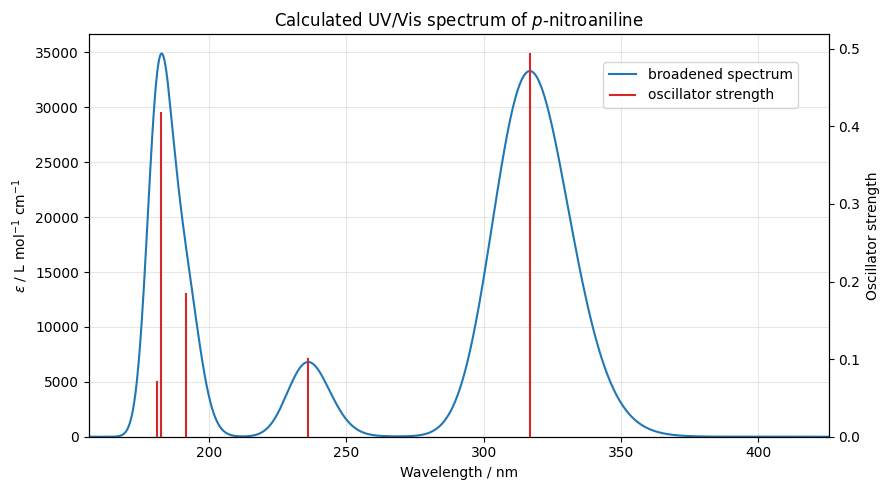

In [8]:
# > 1 eV expressed in wavenumbers (cm**-1)
EV_TO_WAVENUMBER = 8065.543937
# > Integral of the molar extinction coefficient over wavenumbers per unit
# > oscillator strength, in L mol**-1 cm**-1 cm**-1
EPS_INTEGRAL_PER_FOSC = 2.3151e8


def broaden_spectrum(
    energies_ev: np.ndarray,
    fosc: np.ndarray,
    *,
    fwhm_ev: float = 0.4,
    margin_ev: float = 1.0,
    npoints: int = 2000,
) -> tuple[np.ndarray, np.ndarray]:
    """Convolute the discrete transitions with normalized Gaussians."""
    sigma = fwhm_ev / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    grid = np.linspace(max(energies_ev.min() - margin_ev, 0.1), energies_ev.max() + margin_ev, npoints)
    # > Normalized Gaussians on the energy grid (one column per transition)
    gaussians = np.exp(-0.5 * ((grid[:, None] - energies_ev[None, :]) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))
    # > The Gaussians are normalized in eV, hence the conversion to wavenumbers
    epsilon = EPS_INTEGRAL_PER_FOSC / EV_TO_WAVENUMBER * (gaussians @ fosc)
    return grid, epsilon


grid_ev, epsilon = broaden_spectrum(energies_ev, fosc, fwhm_ev=0.4)

fig, ax = plt.subplots(figsize=(9, 5))

# > Broadened spectrum against the wavelength
ax.plot(EV_TO_NM / grid_ev, epsilon, color="tab:blue", label="broadened spectrum")
ax.set_xlabel("Wavelength / nm")
ax.set_ylabel(r"$\epsilon$ / L mol$^{-1}$ cm$^{-1}$")
ax.set_xlim(EV_TO_NM / grid_ev.max(), EV_TO_NM / grid_ev.min())
ax.set_ylim(0.0, 1.05 * epsilon.max())

# > Stick spectrum of the individual transitions on a second axis
ax_sticks = ax.twinx()
ax_sticks.vlines(EV_TO_NM / energies_ev, 0.0, fosc, color="tab:red", label="oscillator strength")
ax_sticks.set_ylabel("Oscillator strength")
ax_sticks.set_ylim(0.0, 1.05 * fosc.max())

ax.set_title("Calculated UV/Vis spectrum of $p$-nitroaniline")
ax.grid(True, alpha=0.3)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
fig.tight_layout()
plt.show()

# > Save the broadened spectrum for further processing
np.savetxt(
    working_dir / "uvvis_spectrum.csv",
    np.column_stack((EV_TO_NM / grid_ev, grid_ev, epsilon)),
    delimiter=",",
    header="wavelength/nm,energy/eV,epsilon/(L mol^-1 cm^-1)",
    comments="",
)

## Summary

In this notebook we demonstrated how the ORCA Python interface can be employed to calculate a UV/Vis spectrum: after a geometry optimization, a TD-DFT calculation provides the vertical excitation energies and oscillator strengths, which `Output.get_absorption_spectrum()` makes directly available. Convoluting these transitions with Gaussians yields a spectrum that can be compared to experiment.

A few points to keep in mind when going beyond this example:
- The number of states (`nroots`) determines the spectral range that is covered. States above the highest calculated excitation are missing from the spectrum.
- The broadening width is an empirical parameter. Values between 0.2 and 0.5 eV are common; a vibrationally resolved spectrum requires an excited-state frequency calculation instead.
- Charge-transfer and Rydberg excitations require range-separated functionals such as `CAM-B3LYP` or `ωB97X-D4`; global hybrids underestimate their energies substantially.
- The same workflow gives the ECD spectrum of a chiral molecule, which ORCA reports alongside the absorption spectrum.